# **MAT 4373: Project** </br> L1 vs. L2 regularization
Here we will be investigating the behaviour of regularization (L1 and L2 regularization) in a high dimensional environment, observing both correlated and uncorrelated datasets. We want to see how regularization performs under various conditions.

### **Dataset: A high-dimensional Gaussian design**

We consider the high-dimensional regime where the number of features exceeds the number of observations (d > n).

We generate data using the same sparse linear model:

y = Xw* + ε

but with d > n, making the problem underdetermined.

In this setting, the design matrix X is not full rank, and the ordinary least squares solution is not unique.

**Goal**  
We study:
- the necessity of regularization in high-dimensional settings,
- why Ridge yields a unique solution,
- why Lasso produces sparse solutions,
- how prediction accuracy and support recovery behave when d > n.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import train_test_split
from data_generation import generate_sparse_linear_data
from data_generation import generate_correlated_sparse_linear_data
from sklearn.metrics import  recall_score, f1_score

#### **Experiment 1: Effects of Dimension**

We observe how a high dimensional environment affects our model, more precisely why regularization is a useful tool in high dimensional settings. We will plot the MSE to the number of dimensions to observe this effect, all other variables will remain unchanged. We will split our experiment into 2 comparisons, independent datasets (rho=0) and correlated datasets (rho=0.7).


c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.075e-03, tolerance: 5.386e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.145e-02, tolerance: 5.825e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

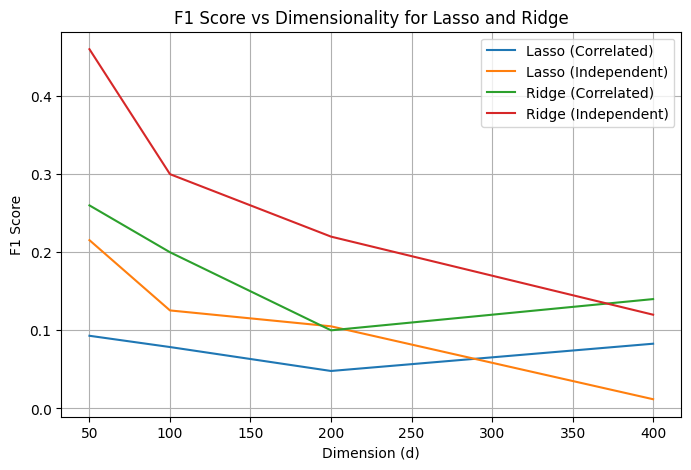

In [28]:
coefficients = [50, 100, 200, 400]
num_trials = 10

results = {
    "d": [],
    "lasso_f1_correlated": [],
    "lasso_f1_uncorrelated": [],
    "ridge_f1_correlated": [],
    "ridge_f1_uncorrelated": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for d in coefficients:
    lasso_f1s_corr = []
    lasso_f1s= []
    ridge_f1s_corr = []
    ridge_f1s = []
    for seed in range(num_trials):

        X, y, w_true, support = generate_sparse_linear_data(n=30, d=d, s=5, sigma=1.5, signal=1.0, random_seeds=seed)
    
        X_corr,y_corr,w_true_corr,support_corr,Sigma_corr=generate_correlated_sparse_linear_data(n=30, d=d, s=5, sigma=1.5, signal=1.0, rho=0.99, random_seeds=seed)

        true_support = np.zeros(len(w_true), dtype=int)
        true_support[support] = 1

        true_support_corr = np.zeros(len(w_true_corr), dtype=int)
        true_support_corr[support_corr] = 1


        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=seed
        )
    
        X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(
            X_corr, y_corr, test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_support = (lasso.coef_ > 1e-3).astype(int)
        lasso_f1 = f1_score(true_support, lasso_support)
        lasso_f1s.append(lasso_f1)

        lasso.fit(X_train_corr, y_train_corr)
        lasso_support = (lasso.coef_ > 1e-3).astype(int)
        lasso_f1 = f1_score(true_support_corr, lasso_support)
        lasso_f1s_corr.append(lasso_f1)
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train_corr, y_train_corr)
        k = np.sum(true_support_corr)

        ridge_topk = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support = np.zeros_like(true_support_corr)
        ridge_support[ridge_topk] = 1

        ridge_f1 = f1_score(true_support_corr, ridge_support)
        ridge_f1s_corr.append(ridge_f1)

        ridge.fit(X_train, y_train)
        k = np.sum(true_support)

        ridge_topk = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support = np.zeros_like(true_support)
        ridge_support[ridge_topk] = 1

        ridge_f1 = f1_score(true_support, ridge_support)
        ridge_f1s.append(ridge_f1)

    results["d"].append(d)
    results["lasso_f1_correlated"].append(np.mean(lasso_f1s_corr))
    results["lasso_f1_uncorrelated"].append(np.mean(lasso_f1s))
    results["ridge_f1_correlated"].append(np.mean(ridge_f1s_corr))
    results["ridge_f1_uncorrelated"].append(np.mean(ridge_f1s))

plt.figure(figsize=(8, 5))
plt.plot(results["d"], results["lasso_f1_correlated"], label="Lasso (Correlated)")
plt.plot(results["d"], results["lasso_f1_uncorrelated"], label="Lasso (Independent)")
plt.plot(results["d"], results["ridge_f1_correlated"], label="Ridge (Correlated)")
plt.plot(results["d"], results["ridge_f1_uncorrelated"], label="Ridge (Independent)")

plt.xlabel("Dimension (d)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Dimensionality for Lasso and Ridge")

plt.legend()
plt.grid(True)
plt.show()

In high dimensions lasso does poorly for both independent and correlated datasets while ridge regression handles both much better.

#### **Experiment 2: Sparse Models**

In this experiment we specifically want to observe the lasso (since ridge regression does not produce sparse models). We want to observe how sparse models will act in high dimensionality. We will compare the sparsity to the penalty term to see the regularization behaviour.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.995e-02, tolerance: 5.282e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.582e-01, tolerance: 5.282e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

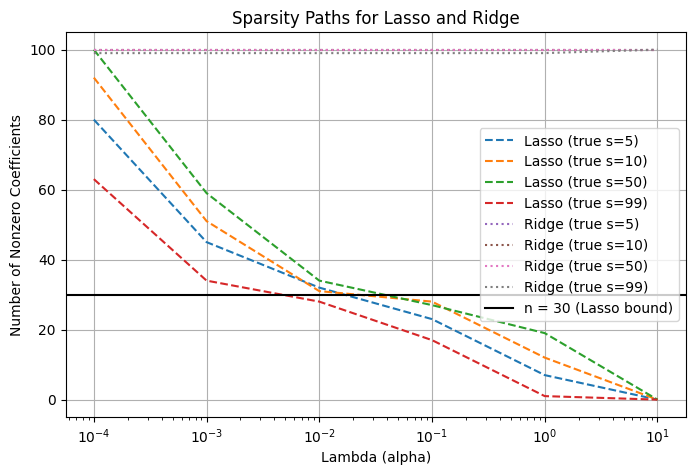

In [29]:
sparsity_values = [5, 10, 50, 99]

lasso_results = {}
ridge_results = {}
alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10]
for sparsity in sparsity_values:
    X_corr,y_corr,w_true_corr,support_corr,Sigma_corr= generate_correlated_sparse_linear_data(n=30, d=100, s=sparsity, sigma=1.0, signal=2.0, rho=0.2,random_seeds=20)
    lasso_nonzero = []
    ridge_nonzero = []
    for alpha in alphas:
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_corr, y_corr)

        ridge = Ridge(alpha=alpha)
        ridge.fit(X_corr, y_corr)
    
        # count nonzero coefficients (choose 1e^-6 as threshold to account for numerical precision, assumes anything smaller is effectively zero)
        lasso_nonzero.append(np.sum(np.abs(lasso.coef_) > 1e-3))

        ridge_nonzero.append(np.sum(np.abs(ridge.coef_) > 1e-3))
    lasso_results[sparsity] = lasso_nonzero
    ridge_results[sparsity] = ridge_nonzero
    
plt.figure(figsize=(8, 5))
for sparsity, vals in lasso_results.items():
    plt.plot(alphas, vals, '--', label=f'Lasso (true s={sparsity})')
for sparsity, vals in ridge_results.items():
    plt.plot(alphas, vals, ':', label=f'Ridge (true s={sparsity})')

plt.axhline(y=30, color='k', linestyle='-', label=f'n = {30} (Lasso bound)')
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Number of Nonzero Coefficients')
plt.title('Sparsity Paths for Lasso and Ridge')
plt.legend()
plt.grid(True)
plt.show()


In theory, Lasso has solutions with at most n coefficients, we are seeing here that lasso has generated more than 30 coefficients for a small enough penalty. This is due to the fact that sparsity is not guaranteed if the design matrix is highly correlated or in high dimensional spaces. Which are both issues encountered here. 

#### **Experiment 3: Support Recovery**

We will observe how our models recover their support depending on the training sample size for both correlated and independent datasets. We will plot the precision of our model against the training size to observe this.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.169e-02, tolerance: 3.117e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.115e-02, tolerance: 6.274e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

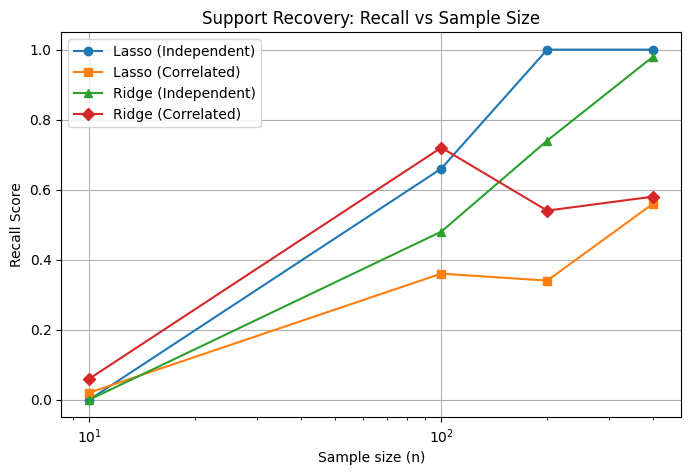

In [30]:
num_trials = 10

n_values = [10, 100, 200, 400]

results = {
    "n": [],
    "lasso_recall_correlated": [],
    "lasso_recall_uncorrelated": [],
    "ridge_recall_correlated": [],
    "ridge_recall_uncorrelated": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for n in n_values:
    # Lists to store recalls for this n across trials
    lasso_recalls = []
    ridge_recalls = []
    lasso_recalls_corr = []
    ridge_recalls_corr = []

    for seed in range(num_trials):
        # Uncorrelated data
        X, y, w_true, non0 = generate_sparse_linear_data(
            n=n, d=1000, s=5, sigma=1.0, signal=0.5, random_seeds=seed
        )
        true_support = np.zeros(1000, dtype=int)
        true_support[non0] = 1

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=seed
        )

        # Lasso (uncorrelated)
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_support = (np.abs(lasso.coef_) > threshold).astype(int)
        lasso_recalls.append(recall_score(true_support, lasso_support))

        # Ridge (uncorrelated)
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        k = len(non0)
        ridge_support = np.zeros_like(ridge.coef_)
        top_k = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support[top_k] = 1
        ridge_recalls.append(recall_score(true_support, ridge_support))

        # Correlated data 
        X_corr, y_corr, w_true_corr, support_corr, _ = generate_correlated_sparse_linear_data(
            n=n, d=1000, s=5, sigma=1.0, signal=0.5, rho=0.9, random_seeds=seed
        )
        true_support_corr = np.zeros(1000, dtype=int)
        true_support_corr[support_corr] = 1

        X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(
            X_corr, y_corr, test_size=0.3, random_state=seed
        )

        # Lasso (correlated)
        lasso_corr = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso_corr.fit(X_train_corr, y_train_corr)
        lasso_support_corr = (np.abs(lasso_corr.coef_) > threshold).astype(int)
        lasso_recalls_corr.append(recall_score(true_support_corr, lasso_support_corr))

        # Ridge (correlated)
        ridge_corr = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge_corr.fit(X_train_corr, y_train_corr)   # <-- fixed: use correlated training data
        k_corr = len(support_corr)
        ridge_support_corr = np.zeros_like(ridge_corr.coef_)
        top_k_corr = np.argsort(np.abs(ridge_corr.coef_))[-k_corr:]
        ridge_support_corr[top_k_corr] = 1
        ridge_recalls_corr.append(recall_score(true_support_corr, ridge_support_corr))

    # After all trials for this n, store the averages
    results["n"].append(n)
    results["lasso_recall_uncorrelated"].append(np.mean(lasso_recalls))
    results["lasso_recall_correlated"].append(np.mean(lasso_recalls_corr))
    results["ridge_recall_uncorrelated"].append(np.mean(ridge_recalls))
    results["ridge_recall_correlated"].append(np.mean(ridge_recalls_corr))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(results["n"], results["lasso_recall_uncorrelated"], marker='o', label="Lasso (Independent)")
plt.plot(results["n"], results["lasso_recall_correlated"], marker='s', label="Lasso (Correlated)")
plt.plot(results["n"], results["ridge_recall_uncorrelated"], marker='^', label="Ridge (Independent)")
plt.plot(results["n"], results["ridge_recall_correlated"], marker='D', label="Ridge (Correlated)")

plt.xscale('log')
plt.xlabel("Sample size (n)")
plt.ylabel("Recall Score")
plt.title("Support Recovery: Recall vs Sample Size")
plt.legend()
plt.grid(True)
plt.show()

We can see that even in high dimensional envionments independent lasso and ridge regression are able to recover their support with a large enough sample size. Meanwhile, correlated lasso and ridge regression still struggle more to recover the true support, even with a large enough sample size.

#### **Experiment 4: Prediction Accuracy**

Finally, in high dimensional environments we will observe how correlation affect the prediction score of our regularization model.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.737e-02, tolerance: 1.199e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.990e-02, tolerance: 1.206e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

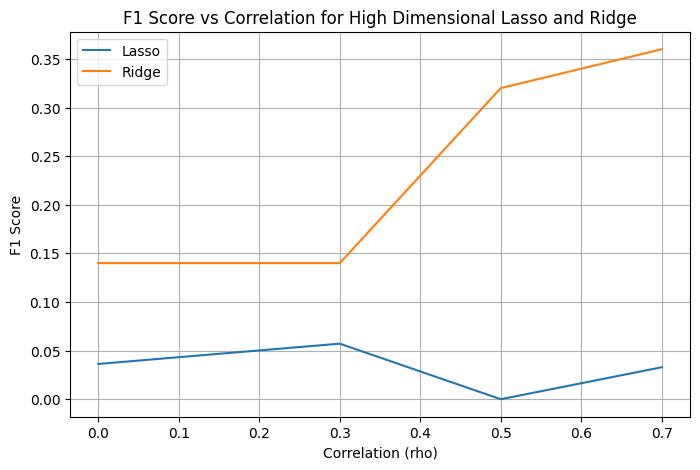

In [31]:
rho_values=[0, 0.3, 0.5, 0.7]

num_trials = 10

results = {
    "rho": [],
    "lasso_f1": [],
    "ridge_f1": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for rho in rho_values:
    lasso_f1s = []
    ridge_f1s = []
    for seed in range(num_trials):
        X_corr,y_corr,w_true_corr,support_corr,Sigma=generate_correlated_sparse_linear_data(rho=rho, n=30, d=500, s=5, sigma=1.5, signal=1.0, random_seeds=seed)

        true_support = np.zeros(len(w_true_corr), dtype=int)
        true_support[support_corr] = 1
    
        X_train, X_test, y_train, y_test = train_test_split(
            X_corr, y_corr, test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_support = (lasso.coef_ > 1e-3).astype(int)
        lasso_f1 = f1_score(true_support, lasso_support)
        lasso_f1s.append(lasso_f1)
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        k = np.sum(true_support)

        ridge_topk = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support = np.zeros_like(true_support)
        ridge_support[ridge_topk] = 1

        ridge_f1 = f1_score(true_support, ridge_support)
        ridge_f1s.append(ridge_f1)

    results["rho"].append(rho)
    results["lasso_f1"].append(np.mean(lasso_f1s))
    results["ridge_f1"].append(np.mean(ridge_f1s))

plt.figure(figsize=(8, 5))
plt.plot(results["rho"], results["lasso_f1"], label="Lasso")
plt.plot(results["rho"], results["ridge_f1"], label="Ridge")

plt.xlabel("Correlation (rho)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Correlation for High Dimensional Lasso and Ridge")

plt.legend()
plt.grid(True)
plt.show()

Clearly, ridge regression does considerably better than lasso in highly correlated spaces.

# References
- scikit-learn Developers. (n.d.). recall_score.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
- Singh, Y. (2022). Precision, Recall, and F1 Score: A Practical Guide Using Scikit-Learn. Proclus Academy.
https://proclusacademy.com/blog/practical/precision-recall-f1-score-sklearn/
- Evidently AI. (2025). Accuracy vs. precision vs. recall in machine learning: what's the difference?
https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall
- DataCamp. (2022). Learning Curves Tutorial: What Are Learning Curves?
https://www.datacamp.com/fr/tutorial/tutorial-learning-curves
- Dataquest. (2018). Tutorial: Learning Curves for Machine Learning in Python for Data Science.
https://www.dataquest.io/blog/learning-curves-machine-learning/
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Springer.
- DataCamp. (2022). Lasso and Ridge Regression in Python Tutorial.
https://www.datacamp.com/tutorial/tutorial-lasso-ridge-regression
- Bhuva, L. (2025). Understanding the Bias-Variance Tradeoff and Regularization in Machine Learning. Medium.
https://medium.com/@lomashbhuva/understanding-the-bias-variance-tradeoff-and-regularization-in-machine-learning-cdc5dd5e260e